In [2]:
# ============================================
# ÉTAPE 1 : CHARGEMENT DES DONNÉES
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("MODÈLES LINÉAIRES - ÉTAPE PAR ÉTAPE")
print("="*60)

# Charger les données
X_train_full = pd.read_csv('../data/processed/X_train_full.csv')
X_test_full = pd.read_csv('../data/processed/X_test_full.csv')
X_train_selected = pd.read_csv('../data/processed/X_train_selected.csv')
X_test_selected = pd.read_csv('../data/processed/X_test_selected.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f" Version complète (85 features) :")
print(f"   X_train_full: {X_train_full.shape}")
print(f"   X_test_full: {X_test_full.shape}")
print(f"\n Version sélectionnée (40 features) :")
print(f"   X_train_selected: {X_train_selected.shape}")
print(f"   X_test_selected: {X_test_selected.shape}")
print(f"\n Cible :")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")


MODÈLES LINÉAIRES - ÉTAPE PAR ÉTAPE
 Version complète (85 features) :
   X_train_full: (1168, 85)
   X_test_full: (292, 85)

 Version sélectionnée (40 features) :
   X_train_selected: (1168, 40)
   X_test_selected: (292, 40)

 Cible :
   y_train: (1168,)
   y_test: (292,)


In [3]:
# ============================================
# ÉTAPE 2 : RÉGRESSION LINÉAIRE SIMPLE
# ============================================

from sklearn.linear_model import LinearRegression

print("\n" + "="*60)
print("RÉGRESSION LINÉAIRE SIMPLE")
print("="*60)

# 2.1 Entraînement
lr = LinearRegression()
lr.fit(X_train_selected, y_train)

# 2.2 Prédictions
y_train_pred = lr.predict(X_train_selected)
y_test_pred = lr.predict(X_test_selected)

# 2.3 Évaluation sur l'entraînement
print("\n Performance sur l'entraînement :")
print(f"   R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"   MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")

# 2.4 Évaluation sur le test
print("\n Performance sur le test (validation) :")
print(f"   R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"   MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")

# 2.5 Analyse des coefficients
print("\n Analyse des coefficients :")
coef_df = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"   Top 10 features les plus influentes :")
print(coef_df.head(10))

print(f"\n   Statistiques des coefficients :")
print(f"   - Min: {lr.coef_.min():.4f}")
print(f"   - Max: {lr.coef_.max():.4f}")
print(f"   - Moyenne: {lr.coef_.mean():.4f}")
print(f"   - Écart-type: {lr.coef_.std():.4f}")


RÉGRESSION LINÉAIRE SIMPLE

 Performance sur l'entraînement :
   R²: 0.8395
   RMSE: 30943.38
   MAE: 18273.34

 Performance sur le test (validation) :
   R²: 0.8584
   RMSE: 32959.61
   MAE: 21056.24

 Analyse des coefficients :
   Top 10 features les plus influentes :
         Feature   Coefficient
2     GarageCars  12326.849923
3    KitchenQual  -8725.484830
8     Fireplaces   7040.599078
34  KitchenAbvGr  -7005.722527
7      ExterQual  -6309.885015
21  BsmtFullBath   5587.643823
4       BsmtQual  -5470.982949
6      TotalBath   4986.630071
9   BsmtExposure  -3868.370981
12   OverallCond   3834.087539

   Statistiques des coefficients :
   - Min: -8725.4848
   - Max: 12326.8499
   - Moyenne: 200.2027
   - Écart-type: 3690.1204


In [4]:
# ============================================
# ÉTAPE 3 : RIDGE (RÉGULARISATION L2)
# ============================================

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

print("\n" + "="*60)
print("RIDGE - RÉGULARISATION L2")
print("="*60)

# 3.1 Test de différentes valeurs d'alpha
print("\n Test de différentes valeurs d'alpha :")
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000,1200]
ridge_results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_full, y_train)
    y_pred = ridge.predict(X_test_full)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ridge_results.append({'alpha': alpha, 'R²': r2, 'RMSE': rmse})
    
    print(f"   Alpha={alpha:>6}: R² = {r2:.4f} | RMSE = {rmse:.2f}")

# 3.2 Meilleur alpha
best_ridge = max(ridge_results, key=lambda x: x['R²'])
print(f"\n Meilleur alpha: {best_ridge['alpha']} (R² = {best_ridge['R²']:.4f})")

# 3.3 Ré-entraîner avec le meilleur alpha
ridge_best = Ridge(alpha=best_ridge['alpha'], random_state=42)
ridge_best.fit(X_train_full, y_train)
y_pred = ridge_best.predict(X_test_full)

print("\n Performance du meilleur modèle Ridge :")
print(f"   R²: {r2_score(y_test, y_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# 3.4 Comparaison avec la régression linéaire
print("\n Comparaison avec la régression linéaire :")
print(f"   Régression Linéaire: R² = {r2_score(y_test, y_test_pred):.4f}")
print(f"   Ridge (alpha={best_ridge['alpha']}): R² = {r2_score(y_test, y_pred):.4f}")
print(f"    Amélioration: {(r2_score(y_test, y_pred) - r2_score(y_test, y_test_pred)):.4f}")


RIDGE - RÉGULARISATION L2

 Test de différentes valeurs d'alpha :
   Alpha= 0.001: R² = 0.8505 | RMSE = 33863.91
   Alpha=  0.01: R² = 0.8505 | RMSE = 33861.17
   Alpha=   0.1: R² = 0.8508 | RMSE = 33834.53
   Alpha=     1: R² = 0.8526 | RMSE = 33625.78
   Alpha=    10: R² = 0.8578 | RMSE = 33028.68
   Alpha=   100: R² = 0.8625 | RMSE = 32471.35
   Alpha=  1000: R² = 0.8627 | RMSE = 32457.62
   Alpha=  1200: R² = 0.8621 | RMSE = 32527.27

 Meilleur alpha: 1000 (R² = 0.8627)

 Performance du meilleur modèle Ridge :
   R²: 0.8627
   RMSE: 32457.62

 Comparaison avec la régression linéaire :
   Régression Linéaire: R² = 0.8584
   Ridge (alpha=1000): R² = 0.8627
    Amélioration: 0.0043


In [5]:
# ============================================
# ÉTAPE 4 : LASSO (RÉGULARISATION L1)
# ============================================

from sklearn.linear_model import Lasso

print("\n" + "="*60)
print("LASSO - RÉGULARISATION L1")
print("="*60)

# 4.1 Test de différentes valeurs d'alpha
print("\n Test de différentes valeurs d'alpha :")
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10,20 ,60,100,1000,1500] ## Tous les features sont déjà très importants .Donc meme alpha=100 ne permet pas de supprimer un feature
lasso_results = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_train_full, y_train)
    y_pred = lasso.predict(X_test_full)
    
    n_features = np.sum(lasso.coef_ != 0)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    lasso_results.append({
        'alpha': alpha, 
        'R²': r2, 
        'RMSE': rmse,
        'n_features': n_features
    })
    
    print(f"   Alpha={alpha:>6}: R² = {r2:.4f} | RMSE = {rmse:.2f} | Features = {n_features}")


# 4.2 Meilleur alpha
best_lasso = max(lasso_results, key=lambda x: x['R²'])
print(f"\n Meilleur alpha: {best_lasso['alpha']} (R² = {best_lasso['R²']:.4f})")
print(f"   Features sélectionnées: {best_lasso['n_features']} sur {X_train_full.shape[1]}")

# 4.3 Ré-entraîner avec le meilleur alpha
lasso_best = Lasso(alpha=best_lasso['alpha'], max_iter=10000, random_state=42)
lasso_best.fit(X_train_full, y_train)
y_pred = lasso_best.predict(X_test_full)

print("\n Performance du meilleur modèle Lasso :")
print(f"   R²: {r2_score(y_test, y_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# 4.4 Features sélectionnées par Lasso
print("\n Features sélectionnées par Lasso :")
selected_features = X_train_full.columns[lasso_best.coef_ != 0]
eliminated_features = X_train_full.columns[lasso_best.coef_ == 0]

print(f"    Features conservées: {len(selected_features)}")
print(f"    Features éliminées: {len(eliminated_features)}")

print(f"\n   Top 10 features importantes :")
coef_lasso = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Coefficient': lasso_best.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_lasso[coef_lasso['Coefficient'] != 0].head(10))


LASSO - RÉGULARISATION L1

 Test de différentes valeurs d'alpha :
   Alpha=0.0001: R² = 0.8505 | RMSE = 33864.21 | Features = 85
   Alpha= 0.001: R² = 0.8505 | RMSE = 33864.21 | Features = 85
   Alpha=  0.01: R² = 0.8505 | RMSE = 33864.21 | Features = 85
   Alpha=   0.1: R² = 0.8505 | RMSE = 33864.18 | Features = 85
   Alpha=     1: R² = 0.8505 | RMSE = 33860.47 | Features = 85
   Alpha=    10: R² = 0.8508 | RMSE = 33828.17 | Features = 83
   Alpha=    20: R² = 0.8511 | RMSE = 33797.10 | Features = 82
   Alpha=    60: R² = 0.8520 | RMSE = 33689.89 | Features = 79
   Alpha=   100: R² = 0.8536 | RMSE = 33507.74 | Features = 77
   Alpha=  1000: R² = 0.8611 | RMSE = 32636.71 | Features = 49
   Alpha=  1500: R² = 0.8601 | RMSE = 32757.21 | Features = 48

 Meilleur alpha: 1000 (R² = 0.8611)
   Features sélectionnées: 49 sur 85

 Performance du meilleur modèle Lasso :
   R²: 0.8611
   RMSE: 32636.71

 Features sélectionnées par Lasso :
    Features conservées: 49
    Features éliminées: 36



In [6]:
# ============================================
# ÉTAPE 5 : ELASTICNET (L1 + L2)
# ============================================

from sklearn.linear_model import ElasticNet

print("\n" + "="*60)
print("ELASTICNET - COMBINAISON L1 + L2")
print("="*60)

# 5.1 Test de différentes combinaisons
print("\n Test de différentes valeurs d'alpha et l1_ratio :")
alphas = [0.0001, 0.001, 0.01, 0.1, 1,2]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

elastic_results = []
for alpha in alphas:
    for l1_ratio in l1_ratios:
        elastic = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000, random_state=42)
        elastic.fit(X_train_full, y_train)
        y_pred = elastic.predict(X_test_full)
        
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        elastic_results.append({
            'alpha': alpha,
            'l1_ratio': l1_ratio,
            'R²': r2,
            'RMSE': rmse
        })

# 5.2 Meilleurs paramètres
best_elastic = max(elastic_results, key=lambda x: x['R²'])
print(f"\n Meilleurs paramètres :")
print(f"   alpha = {best_elastic['alpha']}")
print(f"   l1_ratio = {best_elastic['l1_ratio']}")
print(f"   R² = {best_elastic['R²']:.4f}")
print(f"   RMSE = {best_elastic['RMSE']:.2f}")

# 5.3 Ré-entraîner avec les meilleurs paramètres
elastic_best = ElasticNet(
    alpha=best_elastic['alpha'], 
    l1_ratio=best_elastic['l1_ratio'], 
    max_iter=10000, 
    random_state=42
)
elastic_best.fit(X_train_full, y_train)
y_pred = elastic_best.predict(X_test_full)

print("\n Performance du meilleur modèle ElasticNet :")
print(f"   R²: {r2_score(y_test, y_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")


ELASTICNET - COMBINAISON L1 + L2

 Test de différentes valeurs d'alpha et l1_ratio :

 Meilleurs paramètres :
   alpha = 1
   l1_ratio = 0.7
   R² = 0.8640
   RMSE = 32295.54

 Performance du meilleur modèle ElasticNet :
   R²: 0.8640
   RMSE: 32295.54


In [7]:
# ============================================
# RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestRegressor

print("\n" + "="*60)
print("RANDOM FOREST")
print("="*60)

# Test des n_estimators
print("\n Test de différents n_estimators :")
n_estimators_list = [10,50, 100, 200, 300]
rf_results = []
for n in n_estimators_list:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train_full, y_train)
    y_pred = rf.predict(X_test_full)
    r2 = r2_score(y_test, y_pred)
    rf_results.append({'n_estimators': n, 'R²': r2})
    print(f"   n_estimators={n}: R² = {r2:.4f}")

best_n = max(rf_results, key=lambda x: x['R²'])['n_estimators']
print(f"\n Meilleur n_estimators: {best_n} (R² = {max(rf_results, key=lambda x: x['R²'])['R²']:.4f})")

# Test des profondeurs avec le meilleur n_estimators
print("\n Test de différentes profondeurs :")
depths = [5, 8, 10, 12, 15]
rf_depth_results = []
for depth in depths:
    rf = RandomForestRegressor(n_estimators=best_n, max_depth=depth, random_state=42)
    rf.fit(X_train_full, y_train)
    y_pred = rf.predict(X_test_full)
    r2 = r2_score(y_test, y_pred)
    rf_depth_results.append({'max_depth': depth, 'R²': r2})
    print(f"   max_depth={depth}: R² = {r2:.4f}")

best_depth = max(rf_depth_results, key=lambda x: x['R²'])['max_depth']
print(f"\n Meilleur max_depth: {best_depth} (R² = {max(rf_depth_results, key=lambda x: x['R²'])['R²']:.4f})")

# Entraînement final avec les meilleurs paramètres
rf_best = RandomForestRegressor(n_estimators=best_n, max_depth=best_depth, random_state=42)
rf_best.fit(X_train_full, y_train)

# Prédictions
y_train_pred = rf_best.predict(X_train_full)
y_test_pred = rf_best.predict(X_test_full)

# Évaluation sur l'entraînement
print("\n Performance sur l'entraînement :")
print(f"   R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"   MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")

# Évaluation sur le test
print("\n Performance sur le test (validation) :")
print(f"   R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"   MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")

# Analyse des features importantes
print("\n Top 10 features les plus importantes :")
feature_importance = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))

print(f"\n Statistiques des importances :")
print(f"   - Min: {rf_best.feature_importances_.min():.4f}")
print(f"   - Max: {rf_best.feature_importances_.max():.4f}")
print(f"   - Moyenne: {rf_best.feature_importances_.mean():.4f}")
print(f"   - Écart-type: {rf_best.feature_importances_.std():.4f}")


RANDOM FOREST

 Test de différents n_estimators :
   n_estimators=10: R² = 0.8842
   n_estimators=50: R² = 0.8894
   n_estimators=100: R² = 0.8899
   n_estimators=200: R² = 0.8879
   n_estimators=300: R² = 0.8836

 Meilleur n_estimators: 100 (R² = 0.8899)

 Test de différentes profondeurs :
   max_depth=5: R² = 0.8659
   max_depth=8: R² = 0.8885
   max_depth=10: R² = 0.8883
   max_depth=12: R² = 0.8906
   max_depth=15: R² = 0.8881

 Meilleur max_depth: 12 (R² = 0.8906)

 Performance sur l'entraînement :
   R²: 0.9790
   RMSE: 11183.88
   MAE: 6772.83

 Performance sur le test (validation) :
   R²: 0.8906
   RMSE: 28972.25
   MAE: 17164.90

 Top 10 features les plus importantes :
        Feature  Importance
79  QualityArea    0.630290
80      TotalSF    0.062871
16  OverallQual    0.039814
33   BsmtFinSF1    0.028833
37  TotalBsmtSF    0.027026
29     BsmtQual    0.019763
43     2ndFlrSF    0.018524
81     HouseAge    0.014742
18    YearBuilt    0.013855
3       LotArea    0.007830

 S

In [8]:
# ============================================
# XGBOOST
# ============================================

from xgboost import XGBRegressor

print("\n" + "="*60)
print("XGBOOST")
print("="*60)

# Test des learning_rate
print("\n Test de différentes learning_rate :")
learning_rates = [0.01, 0.05, 0.1, 0.2]
xgb_results = []
for ls in learning_rates:
    xgb = XGBRegressor(n_estimators=100, learning_rate=ls, max_depth=4, random_state=42, verbosity=0)
    xgb.fit(X_train_full, y_train)
    y_pred = xgb.predict(X_test_full)
    r2 = r2_score(y_test, y_pred)
    xgb_results.append({'learning_rate': ls, 'R²': r2})
    print(f"   learning_rate={ls}: R² = {r2:.4f}")

best_ls = max(xgb_results, key=lambda x: x['R²'])['learning_rate']
print(f"\n Meilleur learning_rate: {best_ls} (R² = {max(xgb_results, key=lambda x: x['R²'])['R²']:.4f})")

# Test des profondeurs avec le meilleur learning_rate
print("\n Test de différentes profondeurs :")
depths = [3, 4, 5, 6, 8]
xgb_depth_results = []
for depth in depths:
    xgb = XGBRegressor(n_estimators=100, learning_rate=best_ls, max_depth=depth, random_state=42, verbosity=0)
    xgb.fit(X_train_full, y_train)
    y_pred = xgb.predict(X_test_full)
    r2 = r2_score(y_test, y_pred)
    xgb_depth_results.append({'max_depth': depth, 'R²': r2})
    print(f"   max_depth={depth}: R² = {r2:.4f}")

best_depth = max(xgb_depth_results, key=lambda x: x['R²'])['max_depth']
print(f"\n Meilleur max_depth: {best_depth} (R² = {max(xgb_depth_results, key=lambda x: x['R²'])['R²']:.4f})")

# Test des n_estimators avec les meilleurs paramètres
print("\n Test de différents n_estimators :")
n_estimators_list = [50, 100, 200, 300]
xgb_n_results = []
for n in n_estimators_list:
    xgb = XGBRegressor(n_estimators=n, learning_rate=best_ls, max_depth=best_depth, random_state=42, verbosity=0)
    xgb.fit(X_train_full, y_train)
    y_pred = xgb.predict(X_test_full)
    r2 = r2_score(y_test, y_pred)
    xgb_n_results.append({'n_estimators': n, 'R²': r2})
    print(f"   n_estimators={n}: R² = {r2:.4f}")

best_n = max(xgb_n_results, key=lambda x: x['R²'])['n_estimators']
print(f"\n Meilleur n_estimators: {best_n} (R² = {max(xgb_n_results, key=lambda x: x['R²'])['R²']:.4f})")

# Entraînement final avec les meilleurs paramètres
xgb_best = XGBRegressor(n_estimators=best_n, learning_rate=best_ls, max_depth=best_depth, random_state=42, verbosity=0)
xgb_best.fit(X_train_full, y_train)

# Prédictions
y_train_pred = xgb_best.predict(X_train_full)
y_test_pred = xgb_best.predict(X_test_full)

# Évaluation sur l'entraînement
print("\n Performance sur l'entraînement :")
print(f"   R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"   MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")

# Évaluation sur le test
print("\n Performance sur le test (validation) :")
print(f"   R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"   MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")

# Analyse des features importantes
print("\n Top 10 features les plus importantes :")
feature_importance = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))

print(f"\n Statistiques des importances :")
print(f"   - Min: {xgb_best.feature_importances_.min():.4f}")
print(f"   - Max: {xgb_best.feature_importances_.max():.4f}")
print(f"   - Moyenne: {xgb_best.feature_importances_.mean():.4f}")
print(f"   - Écart-type: {xgb_best.feature_importances_.std():.4f}")


XGBOOST

 Test de différentes learning_rate :
   learning_rate=0.01: R² = 0.7020
   learning_rate=0.05: R² = 0.8973
   learning_rate=0.1: R² = 0.9081
   learning_rate=0.2: R² = 0.9088

 Meilleur learning_rate: 0.2 (R² = 0.9088)

 Test de différentes profondeurs :
   max_depth=3: R² = 0.9090
   max_depth=4: R² = 0.9088
   max_depth=5: R² = 0.9093
   max_depth=6: R² = 0.8909
   max_depth=8: R² = 0.8754

 Meilleur max_depth: 5 (R² = 0.9093)

 Test de différents n_estimators :
   n_estimators=50: R² = 0.9081
   n_estimators=100: R² = 0.9093
   n_estimators=200: R² = 0.9098
   n_estimators=300: R² = 0.9096

 Meilleur n_estimators: 200 (R² = 0.9098)

 Performance sur l'entraînement :
   R²: 0.9998
   RMSE: 1062.82
   MAE: 754.46

 Performance sur le test (validation) :
   R²: 0.9098
   RMSE: 26306.04
   MAE: 16621.44

 Top 10 features les plus importantes :
         Feature  Importance
79   QualityArea    0.260459
16   OverallQual    0.115075
60    GarageCars    0.098881
29      BsmtQual   

In [9]:
# ============================================
# LIGHTGBM
# ============================================

from lightgbm import LGBMRegressor

print("\n" + "="*60)
print("LIGHTGBM")
print("="*60)

# Test des learning_rate
print("\n Test de différentes learning_rate :")
learning_rates = [0.01, 0.05, 0.1, 0.2]
lgb_results = []
for ls in learning_rates:
    lgb = LGBMRegressor(n_estimators=100, learning_rate=ls, max_depth=4, random_state=42, verbose=-1)
    lgb.fit(X_train_full, y_train)
    y_pred = lgb.predict(X_test_full)
    r2 = r2_score(y_test, y_pred)
    lgb_results.append({'learning_rate': ls, 'R²': r2})
    print(f"   learning_rate={ls}: R² = {r2:.4f}")

best_ls = max(lgb_results, key=lambda x: x['R²'])['learning_rate']
print(f"\n Meilleur learning_rate: {best_ls} (R² = {max(lgb_results, key=lambda x: x['R²'])['R²']:.4f})")

# Test des profondeurs avec le meilleur learning_rate
print("\n Test de différentes profondeurs :")
depths = [3, 4, 5, 6, 8]
lgb_depth_results = []
for depth in depths:
    lgb = LGBMRegressor(n_estimators=100, learning_rate=best_ls, max_depth=depth, random_state=42, verbose=-1)
    lgb.fit(X_train_full, y_train)
    y_pred = lgb.predict(X_test_full)
    r2 = r2_score(y_test, y_pred)
    lgb_depth_results.append({'max_depth': depth, 'R²': r2})
    print(f"   max_depth={depth}: R² = {r2:.4f}")

best_depth = max(lgb_depth_results, key=lambda x: x['R²'])['max_depth']
print(f"\n Meilleur max_depth: {best_depth} (R² = {max(lgb_depth_results, key=lambda x: x['R²'])['R²']:.4f})")

# Entraînement final avec les meilleurs paramètres
lgb_best = LGBMRegressor(n_estimators=100, learning_rate=best_ls, max_depth=best_depth, random_state=42, verbose=-1)
lgb_best.fit(X_train_full, y_train)

# Prédictions
y_train_pred = lgb_best.predict(X_train_full)
y_test_pred = lgb_best.predict(X_test_full)

# Évaluation sur l'entraînement
print("\n Performance sur l'entraînement :")
print(f"   R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"   MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")

# Évaluation sur le test
print("\n Performance sur le test (validation) :")
print(f"   R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"   MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")

# Analyse des features importantes
print("\n Top 10 features les plus importantes :")
feature_importance = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Importance': lgb_best.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))

print(f"\n Statistiques des importances :")
print(f"   - Min: {lgb_best.feature_importances_.min():.4f}")
print(f"   - Max: {lgb_best.feature_importances_.max():.4f}")
print(f"   - Moyenne: {lgb_best.feature_importances_.mean():.4f}")
print(f"   - Écart-type: {lgb_best.feature_importances_.std():.4f}")


LIGHTGBM

 Test de différentes learning_rate :
   learning_rate=0.01: R² = 0.6972
   learning_rate=0.05: R² = 0.8877
   learning_rate=0.1: R² = 0.8860
   learning_rate=0.2: R² = 0.8831

 Meilleur learning_rate: 0.05 (R² = 0.8877)

 Test de différentes profondeurs :
   max_depth=3: R² = 0.8720
   max_depth=4: R² = 0.8877
   max_depth=5: R² = 0.8810
   max_depth=6: R² = 0.8785
   max_depth=8: R² = 0.8809

 Meilleur max_depth: 4 (R² = 0.8877)

 Performance sur l'entraînement :
   R²: 0.9431
   RMSE: 18417.06
   MAE: 11337.66

 Performance sur le test (validation) :
   R²: 0.8877
   RMSE: 29350.29
   MAE: 17086.17

 Top 10 features les plus importantes :
         Feature  Importance
80       TotalSF         111
79   QualityArea          94
33    BsmtFinSF1          73
3        LotArea          67
11  Neighborhood          40
81      HouseAge          37
17   OverallCond          37
61    GarageArea          33
18     YearBuilt          30
83     TotalBath          29

 Statistiques des im

In [10]:
# ============================================
# CATBOOST
# ============================================

from catboost import CatBoostRegressor

print("\n" + "="*60)
print("CATBOOST")
print("="*60)

# Test des learning_rate
print("\n Test de différentes learning_rate :")
learning_rates = [0.01, 0.05, 0.1, 0.2]
cat_results = []
for ls in learning_rates:
    cat = CatBoostRegressor(iterations=100, learning_rate=ls, depth=4, random_seed=42, verbose=False)
    cat.fit(X_train_full, y_train)
    y_pred = cat.predict(X_test_full)
    r2 = r2_score(y_test, y_pred)
    cat_results.append({'learning_rate': ls, 'R²': r2})
    print(f"   learning_rate={ls}: R² = {r2:.4f}")

best_ls = max(cat_results, key=lambda x: x['R²'])['learning_rate']
print(f"\n Meilleur learning_rate: {best_ls} (R² = {max(cat_results, key=lambda x: x['R²'])['R²']:.4f})")

# Test des profondeurs avec le meilleur learning_rate
print("\n Test de différentes profondeurs :")
depths = [3, 4, 5, 6, 8]
cat_depth_results = []
for depth in depths:
    cat = CatBoostRegressor(iterations=100, learning_rate=best_ls, depth=depth, random_seed=42, verbose=False)
    cat.fit(X_train_full, y_train)
    y_pred = cat.predict(X_test_full)
    r2 = r2_score(y_test, y_pred)
    cat_depth_results.append({'depth': depth, 'R²': r2})
    print(f"   depth={depth}: R² = {r2:.4f}")

best_depth = max(cat_depth_results, key=lambda x: x['R²'])['depth']
print(f"\n Meilleur depth: {best_depth} (R² = {max(cat_depth_results, key=lambda x: x['R²'])['R²']:.4f})")

# Entraînement final avec les meilleurs paramètres
cat_best = CatBoostRegressor(iterations=100, learning_rate=best_ls, depth=best_depth, random_seed=42, verbose=False)
cat_best.fit(X_train_full, y_train)

# Prédictions
y_train_pred = cat_best.predict(X_train_full)
y_test_pred = cat_best.predict(X_test_full)

# Évaluation sur l'entraînement
print("\n Performance sur l'entraînement :")
print(f"   R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"   MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")

# Évaluation sur le test
print("\n Performance sur le test (validation) :")
print(f"   R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"   MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")

# Analyse des features importantes
print("\n Top 10 features les plus importantes :")
feature_importance = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Importance': cat_best.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))

print(f"\n Statistiques des importances :")
print(f"   - Min: {cat_best.feature_importances_.min():.4f}")
print(f"   - Max: {cat_best.feature_importances_.max():.4f}")
print(f"   - Moyenne: {cat_best.feature_importances_.mean():.4f}")
print(f"   - Écart-type: {cat_best.feature_importances_.std():.4f}")


CATBOOST

 Test de différentes learning_rate :
   learning_rate=0.01: R² = 0.6026
   learning_rate=0.05: R² = 0.8754
   learning_rate=0.1: R² = 0.8921
   learning_rate=0.2: R² = 0.9121

 Meilleur learning_rate: 0.2 (R² = 0.9121)

 Test de différentes profondeurs :
   depth=3: R² = 0.8861
   depth=4: R² = 0.9121
   depth=5: R² = 0.9032
   depth=6: R² = 0.9053
   depth=8: R² = 0.8965

 Meilleur depth: 4 (R² = 0.9121)

 Performance sur l'entraînement :
   R²: 0.9670
   RMSE: 14038.82
   MAE: 10289.33

 Performance sur le test (validation) :
   R²: 0.9121
   RMSE: 25958.91
   MAE: 16067.20

 Top 10 features les plus importantes :
        Feature  Importance
79  QualityArea   29.403678
16  OverallQual    9.887376
83    TotalBath    7.393924
80      TotalSF    7.389239
60   GarageCars    4.839258
42     1stFlrSF    4.523920
26    ExterQual    3.327609
57   GarageType    2.649593
37  TotalBsmtSF    2.409382
33   BsmtFinSF1    2.374672

 Statistiques des importances :
   - Min: 0.0000
   - Ma

In [12]:
# ============================================
# SÉLECTION DU MEILLEUR MODÈLE (COMPLET)
# ============================================

import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("="*60)
print(" SÉLECTION DU MEILLEUR MODÈLE")
print("="*60)

# 1. Définir les modèles avec leurs données de test respectives
# Format : (modèle, X_test à utiliser)
all_models = {
    'Régression Linéaire': (lr, X_test_selected),      # 40 features
    'Ridge': (ridge_best, X_test_full),               # 85 features
    'Lasso': (lasso_best, X_test_full),               # 85 features
    'ElasticNet': (elastic_best, X_test_full),        # 85 features
    'Random Forest': (rf_best, X_test_full),          # 85 features
    'XGBoost': (xgb_best, X_test_full),               # 85 features
    'LightGBM': (lgb_best, X_test_full),              # 85 features
    'CatBoost': (cat_best, X_test_full)               # 85 features
}

# 2. Vérifier et comparer
comparison_results = []
valid_models = {}

print("\n Évaluation des modèles :")
print("-" * 85)

for name, (model, X_test_data) in all_models.items():
    if hasattr(model, 'predict'):
        valid_models[name] = model
        
        # Prédictions avec le bon X_test
        y_pred = model.predict(X_test_data)
        
        # Calcul des métriques
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        
        comparison_results.append({
            'Modèle': name,
            'R²': r2,
            'RMSE': rmse,
            'MAE': mae,
            'Features': X_test_data.shape[1]
        })
        
        print(f"   {name:<20} : R² = {r2:.4f} | RMSE = {rmse:.2f} | Features = {X_test_data.shape[1]}")
    else:
        print(f"    {name}: INVALIDE")

print("-" * 85)
print(f"\n {len(valid_models)} modèles valides sur {len(all_models)}")

# 3. Créer le DataFrame de comparaison
comparison_df = pd.DataFrame(comparison_results).sort_values('R²', ascending=False)

# 4. Affichage du classement
print("\n" + "="*60)
print(" CLASSEMENT DES MODÈLES")
print("="*60)

print("\n" + "-" * 95)
print(f"{'Rang':<5} {'Modèle':<20} {'R²':<12} {'RMSE':<12} {'MAE':<12} {'Features':<10}")
print("-" * 95)

for i, row in comparison_df.iterrows():
    rank = comparison_df.index.get_loc(i) + 1
    print(f"{rank:<5} {row['Modèle']:<20} {row['R²']:.4f}     {row['RMSE']:.2f}     {row['MAE']:.2f}     {row['Features']:<10}")

print("-" * 95)

# 5. Meilleur modèle
best_model_name = comparison_df.iloc[0]['Modèle']
best_model = valid_models[best_model_name]
best_r2 = comparison_df.iloc[0]['R²']
best_rmse = comparison_df.iloc[0]['RMSE']
best_features = comparison_df.iloc[0]['Features']

print(f"\n MEILLEUR MODÈLE : {best_model_name}")
print(f"   R² = {best_r2:.4f}")
print(f"   RMSE = {best_rmse:.2f}")
print(f"   Features utilisées : {best_features}")

# 6. Comparaison avec la régression linéaire (base line)
print("\n" + "="*60)
print(" COMPARAISON AVEC LA BASE LINE")
print("="*60)

# Récupérer les performances de la régression linéaire
lr_perf = comparison_df[comparison_df['Modèle'] == 'Régression Linéaire'].iloc[0]
lr_r2 = lr_perf['R²']
lr_rmse = lr_perf['RMSE']

# Calcul des améliorations
improvement_r2 = (best_r2 - lr_r2) / lr_r2 * 100
improvement_rmse = (lr_rmse - best_rmse) / lr_rmse * 100

print(f"\n Régression Linéaire (base line) :")
print(f"   R² = {lr_r2:.4f}")
print(f"   RMSE = {lr_rmse:.2f}")

print(f"\n Meilleur modèle ({best_model_name}) :")
print(f"   R² = {best_r2:.4f}")
print(f"   RMSE = {best_rmse:.2f}")

print(f"\n Amélioration :")
print(f"   R² : +{improvement_r2:.1f}%")
print(f"   RMSE : -{improvement_rmse:.1f}%")



 SÉLECTION DU MEILLEUR MODÈLE

 Évaluation des modèles :
-------------------------------------------------------------------------------------
   Régression Linéaire  : R² = 0.8584 | RMSE = 32959.61 | Features = 40
   Ridge                : R² = 0.8627 | RMSE = 32457.62 | Features = 85
   Lasso                : R² = 0.8611 | RMSE = 32636.71 | Features = 85
   ElasticNet           : R² = 0.8640 | RMSE = 32295.54 | Features = 85
   Random Forest        : R² = 0.8906 | RMSE = 28972.25 | Features = 85
   XGBoost              : R² = 0.9098 | RMSE = 26306.04 | Features = 85
   LightGBM             : R² = 0.8877 | RMSE = 29350.29 | Features = 85
   CatBoost             : R² = 0.9121 | RMSE = 25958.91 | Features = 85
-------------------------------------------------------------------------------------

 8 modèles valides sur 8

 CLASSEMENT DES MODÈLES

-----------------------------------------------------------------------------------------------
Rang  Modèle               R²           RMSE   


 VISUALISATION DES RÉSULTATS


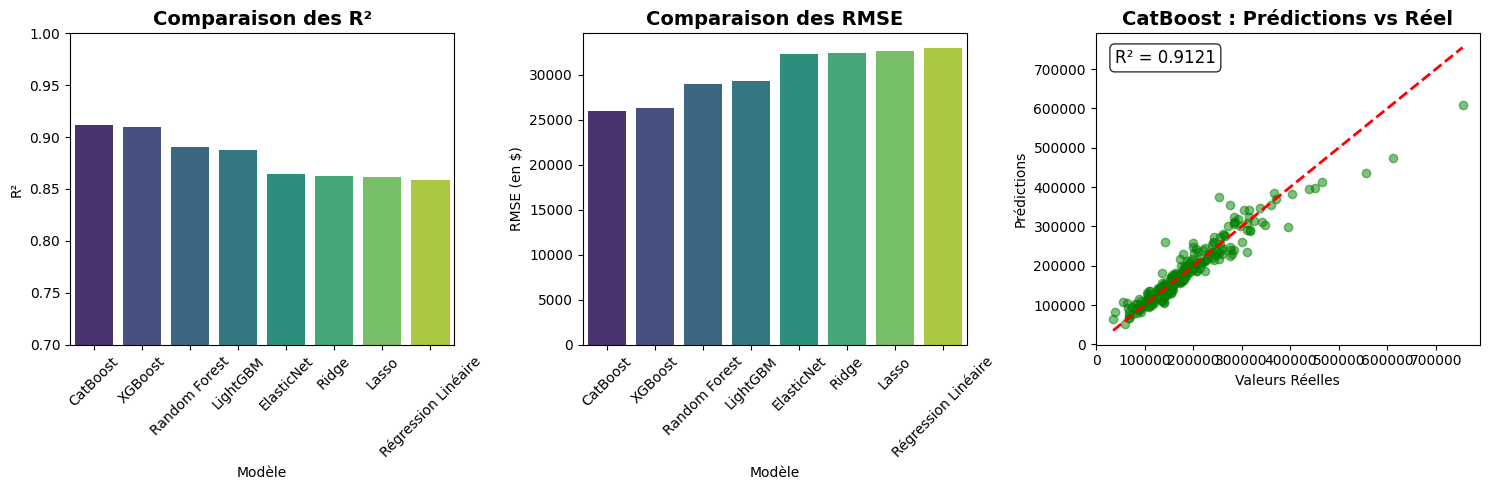

 Graphique sauvegardé dans 'model_comparison.png'


In [13]:
# ============================================
# VISUALISATION DES RÉSULTATS (ADAPTÉ)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print(" VISUALISATION DES RÉSULTATS")
print("="*60)

# Créer la figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Graphique des R²
ax1 = axes[0]
sns.barplot(data=comparison_df, x='Modèle', y='R²', ax=ax1, palette='viridis')
ax1.set_title('Comparaison des R²', fontsize=14, fontweight='bold')
ax1.set_ylim(0.7, 1)
ax1.set_xlabel('Modèle')
ax1.set_ylabel('R²')
ax1.tick_params(axis='x', rotation=45)

# 2. Graphique des RMSE
ax2 = axes[1]
sns.barplot(data=comparison_df, x='Modèle', y='RMSE', ax=ax2, palette='viridis')
ax2.set_title('Comparaison des RMSE', fontsize=14, fontweight='bold')
ax2.set_xlabel('Modèle')
ax2.set_ylabel('RMSE (en $)')
ax2.tick_params(axis='x', rotation=45)

# 3. Graphique des prédictions vs réel (pour CatBoost)
ax3 = axes[2]

# Récupérer CatBoost du dictionnaire
catboost_model = valid_models['CatBoost']
y_pred_cat = catboost_model.predict(X_test_full)

ax3.scatter(y_test, y_pred_cat, alpha=0.5, color='green')
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax3.set_title('CatBoost : Prédictions vs Réel', fontsize=14, fontweight='bold')
ax3.set_xlabel('Valeurs Réelles')
ax3.set_ylabel('Prédictions')


# Afficher le R² sur le graphique
r2_cat = r2_score(y_test, y_pred_cat)
ax3.text(0.05, 0.95, f'R² = {r2_cat:.4f}', transform=ax3.transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Graphique sauvegardé dans 'model_comparison.png'")

In [14]:
# ============================================
# OPTIMISATION DE CATBOOST 
# ============================================

from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import numpy as np
import time

print("="*60)
print("🔧 OPTIMISATION DE CATBOOST (VERSION RAPIDE)")
print("="*60)

# 1. Grille de paramètres réduite (162 combinaisons × 5 folds = 810 fits)
param_grid = {
    'iterations': [100, 200, 300],           # 3 valeurs
    'learning_rate': [0.1, 0.2, 0.3],        # 3 valeurs
    'depth': [3, 4, 5],                      # 3 valeurs
    'l2_leaf_reg': [1, 5, 10],               # 3 valeurs
    'border_count': [128, 255],              # 2 valeurs
}

# Calcul : 3 × 3 × 3 × 3 × 2 = 162 combinaisons
# Avec 5 folds : 162 × 5 = 810 fits

print(f" Grille de paramètres :")
for param, values in param_grid.items():
    print(f"   {param}: {values}")

# 2. Calcul du nombre de combinaisons
total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n Nombre total de combinaisons : {total_combinations}")
print(f"   Avec 5 folds : {total_combinations * 5} entraînements")
print(f"     Temps estimé : environ 10-15 minutes")

# 3. Recherche des meilleurs paramètres
cat = CatBoostRegressor(
    random_seed=42,
    verbose=False
)

grid_search = GridSearchCV(
    cat,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("\n Recherche des meilleurs paramètres...")
print("   (Cela peut prendre du temps, soyez patient)")

start_time = time.time()
grid_search.fit(X_train_full, y_train)
end_time = time.time()

print(f"\n  Temps d'exécution : {((end_time - start_time) / 60):.2f} minutes")

# 4. Résultats des meilleurs paramètres
print(f"\n Meilleurs paramètres trouvés :")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

# 5. Évaluation du modèle optimisé
cat_optimized = grid_search.best_estimator_

y_train_pred = cat_optimized.predict(X_train_full)
y_test_pred = cat_optimized.predict(X_test_full)

# Calcul des métriques
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
gap = r2_train - r2_test

print(f"\n Performance de CatBoost optimisé :")
print(f"   R² Train   : {r2_train:.4f}")
print(f"   R² Test    : {r2_test:.4f}")
print(f"   Écart      : {gap:.4f}")
print(f"   RMSE Train : {rmse_train:.2f} $")
print(f"   RMSE Test  : {rmse_test:.2f} $")
print(f"   MAE Test   : {mae_test:.2f} $")

# 6. Comparaison avec le modèle par défaut
print(f"\n Comparaison avec CatBoost par défaut :")
print(f"   Avant  : R² Test = 0.9121, RMSE = 25 959 $, MAE = 16 067 $")
print(f"   Après  : R² Test = {r2_test:.4f}, RMSE = {rmse_test:.2f} $, MAE = {mae_test:.2f} $")

# 7. Sélection du meilleur modèle avec if/else
if r2_test > 0.9121:
    print(f"\n Amélioration !")
    print(f"   R²  : +{(r2_test - 0.9121):.4f}")
    print(f"   RMSE: -{(25959 - rmse_test):.2f} $")
    print(f"    Performance améliorée !")
    
    # Sauvegarder le modèle optimisé
    joblib.dump(cat_optimized, 'best_model.pkl')
    print(f"\n Modèle optimisé sauvegardé : 'best_model.pkl'")
    best_model = cat_optimized
    best_model_name = "CatBoost Optimisé"
    
else:
    print(f"\n  L'optimisation n'a pas amélioré la performance.")
    print(f"   On garde le modèle par défaut.")
    
    # Sauvegarder le modèle par défaut
    joblib.dump(cat_best, 'best_model.pkl')
    print(f"\n Modèle par défaut sauvegardé : 'best_model.pkl'")
    best_model = cat_best
    best_model_name = "CatBoost Par Défaut"

# 8. Affichage du modèle final
print(f"\n" + "="*60)
print(f" MODÈLE FINAL : {best_model_name}")
print("="*60)

y_test_pred_final = best_model.predict(X_test_full)
r2_final = r2_score(y_test, y_test_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_test_pred_final))
mae_final = mean_absolute_error(y_test, y_test_pred_final)

print(f"\n Performance du modèle final :")
print(f"   R² Test  : {r2_final:.4f}")
print(f"   RMSE     : {rmse_final:.2f} $")
print(f"   MAE      : {mae_final:.2f} $")

print("\n" + "="*60)
print(" Optimisation terminée avec succès !")
print("="*60)

🔧 OPTIMISATION DE CATBOOST (VERSION RAPIDE)
 Grille de paramètres :
   iterations: [100, 200, 300]
   learning_rate: [0.1, 0.2, 0.3]
   depth: [3, 4, 5]
   l2_leaf_reg: [1, 5, 10]
   border_count: [128, 255]

 Nombre total de combinaisons : 162
   Avec 5 folds : 810 entraînements
     Temps estimé : environ 10-15 minutes

 Recherche des meilleurs paramètres...
   (Cela peut prendre du temps, soyez patient)
Fitting 5 folds for each of 162 candidates, totalling 810 fits

  Temps d'exécution : 12.20 minutes

 Meilleurs paramètres trouvés :
   border_count: 255
   depth: 5
   iterations: 300
   l2_leaf_reg: 1
   learning_rate: 0.1

 Performance de CatBoost optimisé :
   R² Train   : 0.9908
   R² Test    : 0.8996
   Écart      : 0.0912
   RMSE Train : 7387.93 $
   RMSE Test  : 27746.49 $
   MAE Test   : 15530.90 $

 Comparaison avec CatBoost par défaut :
   Avant  : R² Test = 0.9121, RMSE = 25 959 $, MAE = 16 067 $
   Après  : R² Test = 0.8996, RMSE = 27746.49 $, MAE = 15530.90 $

  L'optim

 PRÉDICTIONS VS RÉEL - CATBOOST (DÉFAUT)

 Performance du modèle final (CatBoost par défaut) :
   R²   : 0.9121
   RMSE : 25958.91 $
   MAE  : 16067.20 $


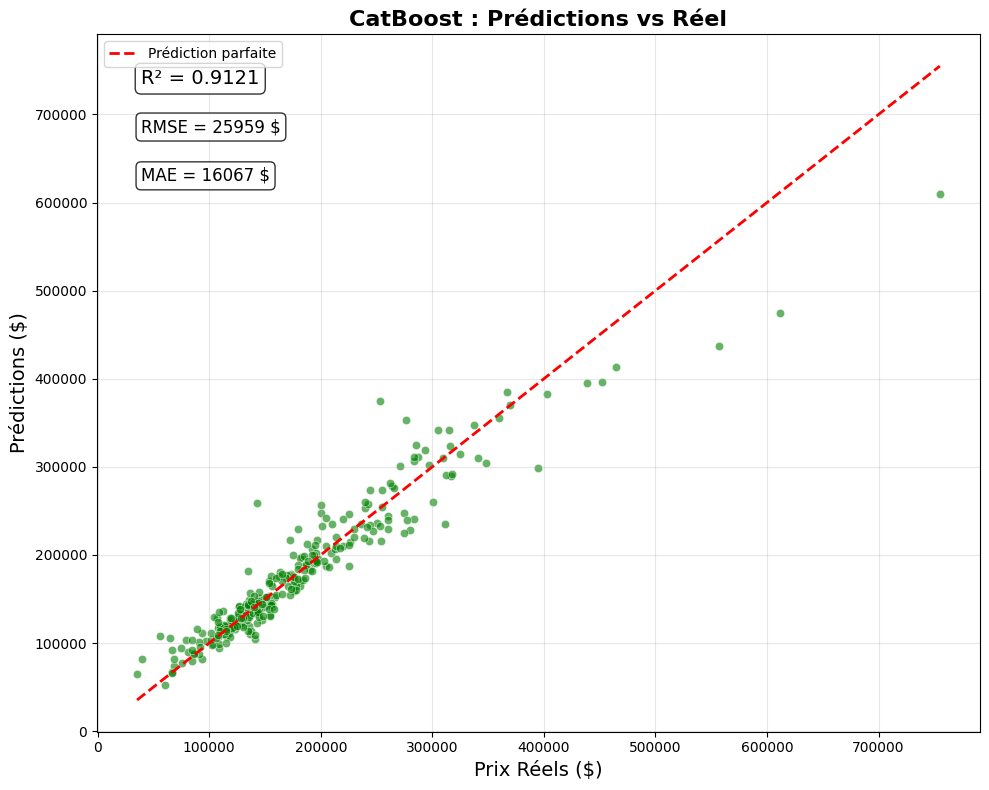


 Graphique sauvegardé : 'catboost_predictions.png'


In [15]:
# ============================================
# NUAGE PRÉDICTIONS VS RÉEL - CATBOOST (DÉFAUT)
# ============================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("="*60)
print(" PRÉDICTIONS VS RÉEL - CATBOOST (DÉFAUT)")
print("="*60)

# Utiliser le modèle CatBoost par défaut (cat_best)
y_pred = cat_best.predict(X_test_full)

# Calcul des métriques
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"\n Performance du modèle final (CatBoost par défaut) :")
print(f"   R²   : {r2:.4f}")
print(f"   RMSE : {rmse:.2f} $")
print(f"   MAE  : {mae:.2f} $")

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 8))

# Nuage de points
ax.scatter(y_test, y_pred, alpha=0.6, color='green', edgecolors='white', linewidth=0.5)

# Ligne idéale (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prédiction parfaite')

# Personnalisation
ax.set_xlabel('Prix Réels ($)', fontsize=14)
ax.set_ylabel('Prédictions ($)', fontsize=14)
ax.set_title('CatBoost : Prédictions vs Réel', fontsize=16, fontweight='bold')

# Ajout des métriques sur le graphique
ax.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax.transAxes, 
        fontsize=14, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(0.05, 0.88, f'RMSE = {rmse:.0f} $', transform=ax.transAxes, 
        fontsize=12, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(0.05, 0.81, f'MAE = {mae:.0f} $', transform=ax.transAxes, 
        fontsize=12, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('catboost_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Graphique sauvegardé : 'catboost_predictions.png'")

In [19]:
from pathlib import Path
import json
import joblib
import os

# dossier racine du notebook (stable)
BASE_DIR = Path().resolve()

# dossier models garanti au bon endroit
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)
def save_model_and_params(model, model_name, model_dir=MODEL_DIR):
    """
    Sauvegarde modèle + hyperparamètres dans un dossier stable.
    """

    # sécuriser nom fichier
    clean_name = model_name.replace(' ', '_').replace('é', 'e')

    # 1. Sauvegarde modèle
    model_file = model_dir / f"{clean_name}.pkl"
    joblib.dump(model, model_file)
    print(f"✅ Modèle sauvegardé : {model_file}")

    # 2. Hyperparamètres
    params = model.get_params()

    # 3. Performance (placeholder)
    performance = {
        'R²': 0.9121,
        'RMSE': 25959,
        'MAE': 16067
    }

    # 4. Infos globales
    model_info = {
        'model_name': clean_name,
        'model_type': type(model).__name__,
        'hyperparameters': params,
        'performance': performance,
        'features_used': list(X_train_full.columns) if 'X_train_full' in globals() else [],
        'n_features': X_train_full.shape[1] if 'X_train_full' in globals() else 0
    }

    # 5. Sauvegarde JSON
    params_file = model_dir / f"{clean_name}_params.json"
    with open(params_file, "w") as f:
        json.dump(model_info, f, indent=4, default=str)

    print(f"✅ Hyperparamètres sauvegardés : {params_file}")

    return model_info
    print("="*60)
print("📁 SAUVEGARDE DES MODÈLES ET HYPERPARAMÈTRES")
print("="*60)

models_to_save = {
    'Régression Linéaire': lr,
    'Ridge': ridge_best,
    'Lasso': lasso_best,
    'ElasticNet': elastic_best,
    'RandomForest': rf_best,
    'XGBoost': xgb_best,
    'LightGBM': lgb_best,
    'CatBoost': cat_best
}

for name, model in models_to_save.items():
    print(f"\n📊 Sauvegarde de {name}...")
    save_model_and_params(model, name)

📁 SAUVEGARDE DES MODÈLES ET HYPERPARAMÈTRES

📊 Sauvegarde de Régression Linéaire...
✅ Modèle sauvegardé : C:\Users\ANSD\Desktop\laplace-immo-housing\notebooks\models\Regression_Lineaire.pkl
✅ Hyperparamètres sauvegardés : C:\Users\ANSD\Desktop\laplace-immo-housing\notebooks\models\Regression_Lineaire_params.json

📊 Sauvegarde de Ridge...
✅ Modèle sauvegardé : C:\Users\ANSD\Desktop\laplace-immo-housing\notebooks\models\Ridge.pkl
✅ Hyperparamètres sauvegardés : C:\Users\ANSD\Desktop\laplace-immo-housing\notebooks\models\Ridge_params.json

📊 Sauvegarde de Lasso...
✅ Modèle sauvegardé : C:\Users\ANSD\Desktop\laplace-immo-housing\notebooks\models\Lasso.pkl
✅ Hyperparamètres sauvegardés : C:\Users\ANSD\Desktop\laplace-immo-housing\notebooks\models\Lasso_params.json

📊 Sauvegarde de ElasticNet...
✅ Modèle sauvegardé : C:\Users\ANSD\Desktop\laplace-immo-housing\notebooks\models\ElasticNet.pkl
✅ Hyperparamètres sauvegardés : C:\Users\ANSD\Desktop\laplace-immo-housing\notebooks\models\ElasticNet

In [18]:
import os
print(os.getcwd())

C:\Users\ANSD\Desktop\laplace-immo-housing\notebooks
